In [3]:
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np

In [4]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [5]:
origin = load_data('language_math_scores')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()


[data] https://data.hossam.kr/data/lab11_/language_math_scores.xlsx
[desc] 어느 학급의 언어영역과 수리영역 점수를 기록한 가상의 데이터 셋

field     type    description
--------  ------  -------------
언어영역  INT     언어영역 점수
수리영역  INT     수리영역 점수


===== 데이터 크기 확인 =====
데이터셋 크기: (50, 2)
열 개수: 2
행 개수: 50

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   언어영역    50 non-null     int64
 1   수리영역    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes
None


,언어영역,수리영역
0,66,66
1,58,70
2,73,74
3,52,58
4,72,79


📘 #02. 탐색적 데이터 분석

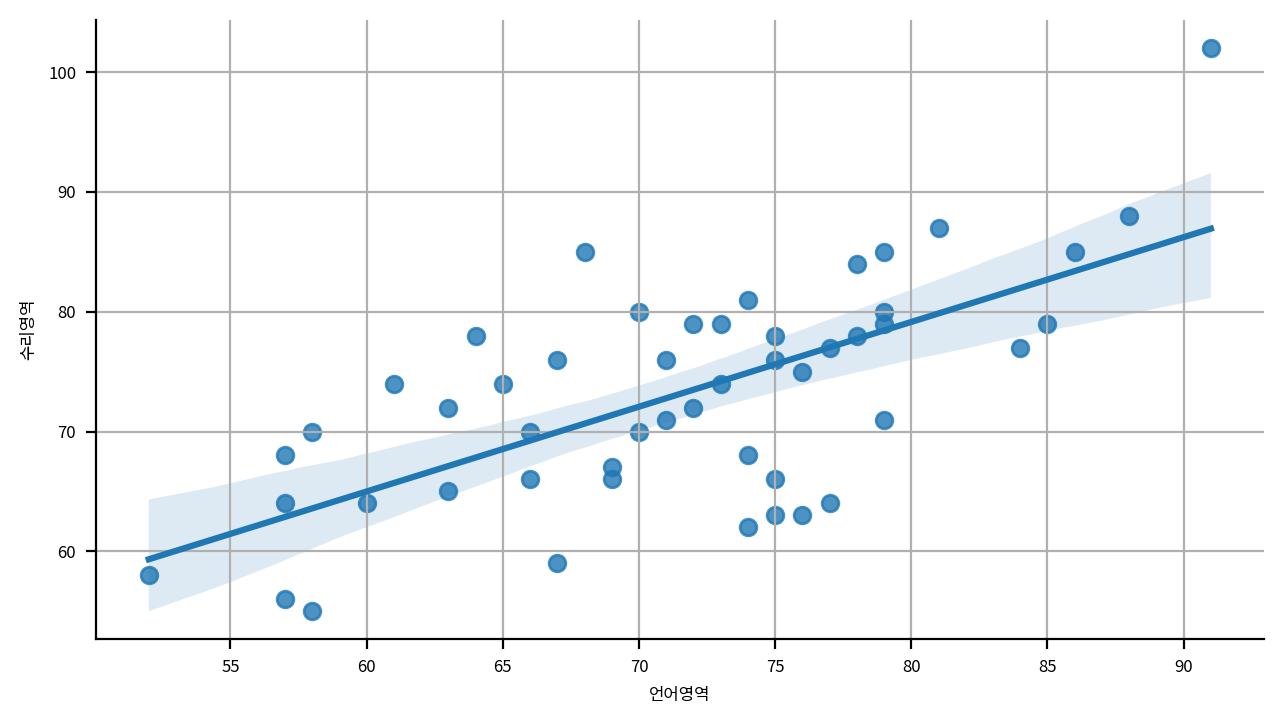

In [6]:
# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
# 2) LM Plot 그리기
g = sb.lmplot(data=origin, x="언어영역", y="수리영역")
g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])
plt.grid()
# 3) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

📘 #03. 공분산

In [8]:
c = np.cov(origin['언어영역'], origin['수리영역'])
c

array([[76.86693878, 54.39020408],
       [54.39020408, 85.57714286]])

In [10]:
"공분산: {0}".format(c[0][1])

'공분산: 54.390204081632646'

📚 [LAB 11] 2. 상관분석

In [11]:
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr

In [12]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [13]:
origin = load_data('language_math_scores')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab11_/language_math_scores.xlsx
[desc] 어느 학급의 언어영역과 수리영역 점수를 기록한 가상의 데이터 셋

field     type    description
--------  ------  -------------
언어영역  INT     언어영역 점수
수리영역  INT     수리영역 점수


===== 데이터 크기 확인 =====
데이터셋 크기: (50, 2)
열 개수: 2
행 개수: 50

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   언어영역    50 non-null     int64
 1   수리영역    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes
None


,언어영역,수리영역
0,66,66
1,58,70
2,73,74
3,52,58
4,72,79


📘 #02. 상관분석의 가정

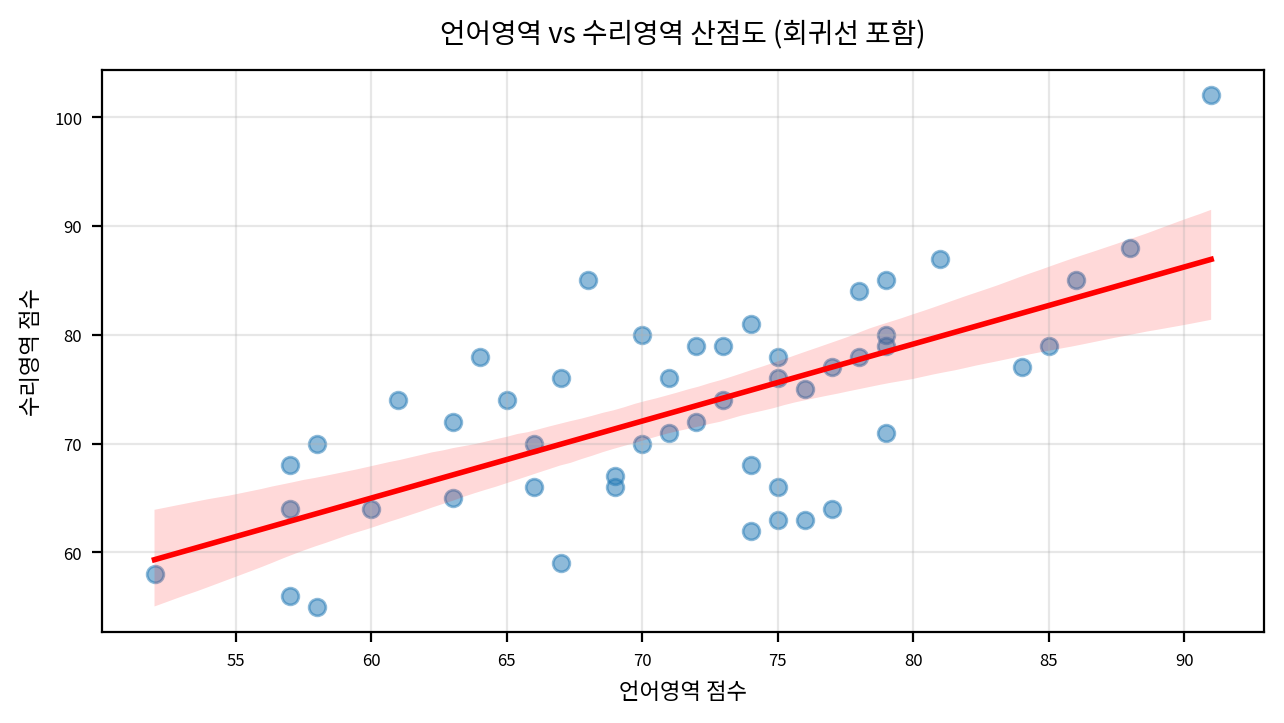

In [14]:
# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1         # 그래프 행 수
cols = 1         # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) Scatter Plot 그리기 (회귀선 포함)
sb.regplot(
    data=origin,
    x='언어영역',
    y='수리영역',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'linewidth': 2}
)

# 3) 그래프 꾸미기
ax.set_title('언어영역 vs 수리영역 산점도 (회귀선 포함)', fontsize=10, pad=10)
ax.set_xlabel('언어영역 점수', fontsize=8)
ax.set_ylabel('수리영역 점수', fontsize=8)
ax.grid(True, alpha=0.3)  # 배경 격자 표시

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()          # 그래프 화면 출력
plt.close()         # 그래프 작업 종료


<인사이트><br>
🍭점들이 대체로 우상향(오른쪽 위로) 하는 패턴을 보임<br>
🍭빨간색 회귀선을 중심으로 점들이 모여 있어 선형 관계가 있어 보임<br>
🍭이는 언어영역 점수가 높을수록 수리영역 점수도 높아지는 양의 상관관계를 시사함<br>
🍭하지만 눈으로만 판단하면 주관적일 수 있으므로, 통계적 검정을 통해 선형성을 확인해야 함

4) 선형성 통계적 검정 (Ramsey RESET Test)<br>
🍭Ramsey RESET Test는 회귀 모델이 선형인지 검정하는 방법<br>
🍭p > 0.05: 선형성 적합 (피어슨 상관계수 사용 가능)<br>
🍭p ≤ 0.05: 선형성 위반 (스피어만 상관계수 사용 권장)<br>

In [15]:
x = origin['언어영역']
y = origin['수리영역']
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
reset = linear_reset(model, power=2, use_f=True)
# 선형성 적합 여부 (True=적합, False=부적합)
linearity_ok = reset.pvalue > 0.05
print(f"Ramsey RESET Test : {'선형성 적합' if linearity_ok else '선형성 위반'} (p-value: {reset.pvalue:.4f})")

Ramsey RESET Test : 선형성 적합 (p-value: 0.1884)


📝 2. 분포 왜도를 통한 이상치 점검<br>
피어슨 상관계수(Pearson r)는 이상치에 매우 민감하다.<br>
즉, 데이터의 대부분이 규칙적으로 퍼져 있어도 극단값 하나가 상관계수를 크게 끌어올리거나 끌어내릴 수 있다.<br>
상관분석에 사용되는 변수 중 하나라도 이상치가 존재한다면 스피어만 상관계수를 사용해야 한다.

In [16]:
# 이상치와 왜도 검정
data = origin[['언어영역', '수리영역']]
results = {}

for col in data.columns:
    temp = data[col].dropna()
    
    # 왜도 계산
    skew_original = temp.skew()
    
    # Z-score 기반 이상치 탐지 (|z| > 3)
    z_scores = zscore(temp)
    outlier_count = int(np.sum(np.abs(z_scores) > 3))
    
    # 로그 변환 후 왜도 계산 (음수 대비 +1)
    data_log = np.log1p(temp - temp.min() + 1)
    skew_log = data_log.skew()
    
    # 로그 변환 필요 여부 판단
    need_log = (abs(skew_original) > 1) and (abs(skew_log) < abs(skew_original))
    
    results[col] = {
        'original_skew': skew_original,
        'log_skew': skew_log,
        'outliers(|z|>3)': outlier_count,
        'log_recommended': need_log
    }

# 결과 DataFrame 정리
results_df = pd.DataFrame(results).T
display(results_df)

# 이상치 점검 결과
outlier_flag = any(results_df['outliers(|z|>3)'] > 0)

if outlier_flag:
    print("이상치가 발견되어 스피어만 상관계수 사용")
else:
    print("이상치가 발견되지 않아 피어슨 상관계수 사용")


,original_skew,log_skew,outliers(|z|>3),log_recommended
언어영역,-0.102559,-1.735952,0,False
수리영역,0.367414,-1.529107,1,False


이상치가 발견되어 스피어만 상관계수 사용


[언어영역] - 왜도: -0.103 (정규분포에 가까움) - 이상치 개수: 0개<br>
[수리영역] - 왜도: 0.367 (정규분포에 가까움) - 이상치 개수: 1개 - 이상치가 1개 발견되어<br>
스피어만 상관계수를 사용해야 함<br>

📘 #03. 상관분석

📝 1. 피어슨 상관계수

In [19]:
pearson_r, pearson_p = pearsonr(origin['언어영역'], origin['수리영역'])
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(pearson_r,pearson_p, "대립" if pearson_p <= 0.05 else "귀무")

'statistic: 0.671, p-value: 0.000, 대립가설 채택'

📝 2. 스피어만 상관계수

In [ ]:
spearman_r, spearman_p = spearmanr(origin['언어영역'], origin['수리영역'])
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(spearman_r, spearman_p, "대립" if spearman_p <=0.05 else "귀무")

'statistic: 0.599, p-value: 0.000, 대립가설 채택'

📝 3. 가정에 따른 상관계수 선택<br>
선형 + 왜도/이상치 영향 적음 → 피어슨 우선<br>
단조 비선형 또는 이상치 많음/왜도 큼 → 스피어만 우선<br>

In [23]:
# 1. 상관계수 선택
if linearity_ok and not outlier_flag:
    chosen = 'pearson'
    corr, pval = pearson_r, pearson_p
    rationale = '선형성 만족 + 왜도/이상치 영향 작음으로 판단'
else:
    chosen = 'spearman'
    corr, pval = spearman_r, spearman_p
    rationale = '비선형(또는 이상치 영향) 가능성 고려'

print('=' * 50)
print('📊 상관계수 요약')
print('=' * 50)
print(f"Pearson r: {pearson_r:.3f}, p-value: {pearson_p:.4f}")
print(f"Spearman rho: {spearman_r:.3f}, p-value: {spearman_p:.4f}")

print('\n' + '=' * 50)
print('✅ 최종 선택 결과')
print('=' * 50)
print(f"선택된 방법: {chosen}")
print(f"상관계수: {corr:.3f}")
print(f"p-value: {pval:.4f}")
print(f"선택 근거: {rationale}")
print('=' * 50)


📊 상관계수 요약
Pearson r: 0.671, p-value: 0.0000
Spearman rho: 0.599, p-value: 0.0000

✅ 최종 선택 결과
선택된 방법: spearman
상관계수: 0.599
p-value: 0.0000
선택 근거: 비선형(또는 이상치 영향) 가능성 고려


📝 4. 상관행렬

In [24]:
corr_matrix = origin[['언어영역', '수리영역']].corr(method=chosen)
corr_matrix

,언어영역,수리영역
언어영역,1.000000,0.599095
수리영역,0.599095,1.000000


📝 5. 상관계수 히트맵

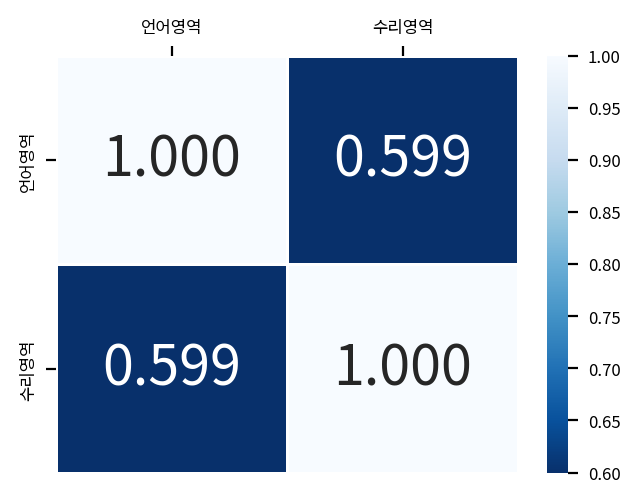

In [25]:
# 1) 그래프 초기화
width_px = 650 # 그래프 가로 크기
height_px = 500 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) heatmap 그리기
sb.heatmap(data=corr_matrix, annot=True, fmt="0.3f", linewidth=0.5,
cmap="Blues_r", annot_kws={"size": 20})
# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top() # x축의 변수 이름을 상단으로 이동
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료